# install

In [ ]:
! pip install lightning
! pip install torchview
! pip install torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 58.0 MB/s eta 0:00:00


# import

In [ ]:
# ===============================
# PyTorch Core Modules
# ===============================
import torch  # Core tensor operations
from torch import Tensor
import torch.nn as nn  # Neural network layers
import torch.nn.functional as F  # Functional API for activations, losses, etc.
import torch.optim as optim  # Optimizers
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset utilities

# ===============================
# PyTorch Ecosystem
# ===============================
import pytorch_lightning as pl  # High-level training framework
import torchmetrics  # Model evaluation metrics
from torchview import draw_graph  # Model visualization
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor # Callbacks

# ===============================
# TorchVision - For image data
# ===============================
import torchvision  # Pretrained models and datasets
import torchvision.transforms as transforms  # Image preprocessing utilities
import torchvision.models as models
from torchvision.io import read_image, decode_image
from torchvision.models import resnet50, ResNet50_Weights, MobileNet_V3_Large_Weights

# ===============================
# Scikit-learn - Data generation and preprocessing
# ===============================
from sklearn.datasets import make_regression  # Synthetic regression data
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.preprocessing import MinMaxScaler  # Feature scaling

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt  # Plotting utilities

# ===============================
# Numerical Computing
# ===============================
import numpy as np  # Array operations
import math  # Basic mathematical functions

from PIL import Image
import requests
import io
import json

import os

# Dataset

## Load

In [ ]:
import kagglehub

path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")

print("Path to dataset files:", path)
# %ls -R {path}

100%|██████████| 937M/937M [00:23<00:00, 41.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16


## PlantDataset


In [ ]:
from torchvision.io import read_image

class PlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        self.labels = []
        self.class_to_idx = {}
        idx = 0
        for class_name in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                self.class_to_idx[class_name] = idx
                for image_file in os.listdir(class_dir):
                    if image_file.endswith('.jpg') or image_file.endswith('.png'):
                        self.image_files.append(os.path.join(class_dir, image_file))
                        self.labels.append(idx)
                idx += 1

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = read_image(img_path).float() / 255.0 # Read as float and scale to [0, 1]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## transforms



In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)), # Changed from 128x128 to 32x32
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Changed from
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## DataLoader


In [ ]:
train_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Train_Set_Folder'
val_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Validation_Set_Folder'
test_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Test_Set_Folder'

train_dataset = PlantDataset(root_dir=train_root_dir, transform=train_transforms)
val_dataset = PlantDataset(root_dir=val_root_dir, transform=val_transforms)
test_dataset = PlantDataset(root_dir=test_root_dir, transform=test_transforms)

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in validation DataLoader: {len(val_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Number of batches in training DataLoader: 375
Number of batches in validation DataLoader: 48
Number of batches in test DataLoader: 47


## Save classees idx

In [ ]:
import os, json

# Ensure model directory exists
os.makedirs("model", exist_ok=True)

# Guard: only proceed if train_dataset exists
if 'train_dataset' not in globals():
    raise NameError("train_dataset not defined. Create dataset before running this cell.")

class_to_idx = train_dataset.class_to_idx  # {class_name: idx}
idx_to_class = {str(v): k for k, v in class_to_idx.items()}  # JSON keys as strings

with open("model/class_map.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved model/class_map.json with", len(idx_to_class), "classes.")

Saved model/class_map.json with 30 classes.


# efficientnet b0

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B0_Weights

class EfficientNetB0PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B0_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b0(weights=weights)

        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        # optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    # def on_train_epoch_start(self):
    #     if self.current_epoch == 1:
    #         for param in self.model.features.parameters():
    #             param.requires_grad = True
    #         self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    #         print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB0 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b0_lightning_model = EfficientNetB0PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B0 Plant Classifier defined.")
print(efficientnet_b0_lightning_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]

✅ EfficientNet B0 Plant Classifier defined.
EfficientNetB0PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b0-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Make sure the bar updates properly in Kaggle
progress_bar = TQDMProgressBar(refresh_rate=1)

# Optional: enable detailed logs
logger = CSVLogger(save_dir="logs/", name="efficientnet_b0")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback, progress_bar],
    logger=logger,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1
)

print("Starting EfficientNet B0 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b0_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B0 Plant Dataset testing...")

test_results_b0 = trainer.test(efficientnet_b0_lightning_model, test_dataloader)

test_loss_b0 = test_results_b0[0]['test_loss']
test_acc_b0 = test_results_b0[0]['test_acc']
test_precision_b0 = test_results_b0[0]['test_precision']
test_recall_b0 = test_results_b0[0]['test_recall']
test_f1_b0 = test_results_b0[0]['test_f1']

print(f"\nEfficientNet B0 Test Results:")
print(f"  Loss: {test_loss_b0:.4f}")
print(f"  Accuracy: {test_acc_b0:.4f}")
print(f"  Precision (macro): {test_precision_b0:.4f}")
print(f"  Recall (macro): {test_recall_b0:.4f}")
print(f"  F1 Score (macro): {test_f1_b0:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type                | Params | Mode
---------------------------------------------------------
0 | model     | EfficientNet        | 4.0 M  | eval
1 | criterion | CrossEntropyLoss    | 0      | eval
2 | accuracy  | MulticlassAccuracy  | 0      | eval
3 | precision | MulticlassPrecision | 0      | eval
4 | recall    | MulticlassRecall    | 0      | eval
5 | f1_score  | MulticlassF1Score   | 0      | eval
---------------------------------------------------------
4.0 M     Trainable params
0         Non-trainable params
4.0 M     Total params
16.184    Total estimated model params size (MB)
0         Modules in train mode
342       Modules in eval mode


Starting EfficientNet B0 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loops/fit_loop.py:527: Found 343 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

...


Starting EfficientNet B0 Plant Dataset testing...


/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8565710186958313     │
│          test_f1          │    0.2726167142391205     │
│         test_loss         │    0.4607400894165039     │
│      test_precision       │    0.2905806303024292     │
│        test_recall        │    0.2589390277862549     │
└───────────────────────────┴───────────────────────────┘


EfficientNet B0 Test Results:
  Loss: 0.4607
  Accuracy: 0.8566
  Precision (macro): 0.2906
  Recall (macro): 0.2589
  F1 Score (macro): 0.2726


# efficientnet b1

## wrapper

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B1_Weights

class EfficientNetB1PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B1_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b1(weights=weights)

        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        # self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        # self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        # self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        # self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

        self.test_precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')


    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.train_accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.test_accuracy(outputs, labels))
        self.log('test_precision', self.test_precision(outputs, labels))
        self.log('test_recall', self.test_recall(outputs, labels))
        self.log('test_f1', self.test_f1(outputs, labels))
        return loss


    def configure_optimizers(self):
        # optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    # def on_train_epoch_start(self):
    #     if self.current_epoch == 1:
    #         for param in self.model.features.parameters():
    #             param.requires_grad = True
    #         self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    #         print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB1 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b1_lightning_model = EfficientNetB1PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B1 Plant Classifier defined.")
print(efficientnet_b1_lightning_model)

✅ EfficientNet B1 Plant Classifier defined.
EfficientNetB1PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

## train

In [15]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b1-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Make sure the bar updates properly in Kaggle
progress_bar = TQDMProgressBar(refresh_rate=1)

# Optional: enable detailed logs
logger = CSVLogger(save_dir="logs/", name="efficientnet_b0")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback, progress_bar],
    logger=logger,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1
)

print("Starting EfficientNet B1 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b1_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B1 Plant Dataset testing...")

test_results_b1 = trainer.test(efficientnet_b1_lightning_model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type                | Params | Mode 
---------------------------------------------------------------
0 | model          | EfficientNet        | 6.6 M  | train
1 | criterion      | CrossEntropyLoss    | 0      | train
2 | train_accuracy | MulticlassAccuracy  | 0      | train
3 | val_accuracy   | MulticlassAccuracy  | 0      | train
4 | test_accuracy  | MulticlassAccuracy  | 0      | train
5 | test_precision | MulticlassPrecision | 0      | train
6 | test_recall    | MulticlassRecall    | 0      | train
7 | test_f1    

Starting EfficientNet B1 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.067 >= min_delta = 0.0. New best score: 0.171
INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 3750: 'val_acc' reached 0.94059 (best 0.94059), saving model to '/content/checkpoints/best-efficientnet-b1-model-v1.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting EfficientNet B1 Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9492995142936707     │
│          test_f1          │     0.469755619764328     │
│         test_loss         │    0.16728198528289795    │
│      test_precision       │    0.4789542853832245     │
│        test_recall        │     0.461678683757782     │
└───────────────────────────┴───────────────────────────┘

## save .pt

In [16]:
# after training
# trainer.fit(efficientnet_b1_lightning_model, train_dataloader, val_dataloader)

# path to the best checkpoint from your ModelCheckpoint callback
best_ckpt_path = checkpoint_callback.best_model_path
print(f"Best checkpoint path: {best_ckpt_path}")

# load model from checkpoint
model = efficientnet_b1_lightning_model.__class__.load_from_checkpoint(best_ckpt_path)

# optional: move to CPU for saving (especially if training was on GPU)
import torch
model = model.to(torch.device("cpu"))
model.eval()

# save the full model (architecture + weights) as .pt
torch.save(model, "model_best_full.pt")

# OR: save only the state_dict (weights only)
torch.save(model.state_dict(), "model_best_weights.pt")

print("Saved model files: model_best_full.pt and model_best_weights.pt")

Best checkpoint path: /content/checkpoints/best-efficientnet-b1-model-v1.ckpt
Saved model files: model_best_full.pt and model_best_weights.pt


## predict

In [17]:
print(idx_to_class)

{'0': 'paddy', '1': 'cantaloupe', '2': 'orange', '3': 'soybeans', '4': 'sweet potatoes', '5': 'coconut', '6': 'curcuma', '7': 'pomelo', '8': 'kale', '9': 'watermelon', '10': 'cassava', '11': 'eggplant', '12': 'spinach', '13': 'pineapple', '14': 'tobacco', '15': 'melon', '16': 'bilimbi', '17': 'galangal', '18': 'banana', '19': 'longbeans', '20': 'shallot', '21': 'papaya', '22': 'cucumber', '23': 'ginger', '24': 'waterapple', '25': 'corn', '26': 'peper chili', '27': 'guava', '28': 'aloevera', '29': 'mango'}


In [ ]:
from google.colab import files
from PIL import Image
import torch
from torchvision import transforms

# 1. Upload image from local
uploaded = files.upload()  # opens a file picker
image_path = list(uploaded.keys())[0]
print(f"Uploaded file: {image_path}")

# 2. Load model from checkpoint
# model = efficientnet_b1_lightning_model.__class__.load_from_checkpoint(best_ckpt_path)
# model.eval()

# 3. Define same preprocessing as used during training
preprocess = transforms.Compose([
    transforms.Resize((224,224)),   # adjust if your training size differs
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class_to_idx = train_dataset.class_to_idx  # {class_name: idx}
idx_to_class = {v: k for k, v in class_to_idx.items()}  # flip mapping

# 4. Predict function
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0)  # add batch dimension

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        predicted_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_idx].item()

        predicted_class_name = idx_to_class[predicted_idx]

    return predicted_class_name, confidence

# 5. Run prediction
pred_class, confidence = predict_image(image_path)
print(f"Predicted class: {pred_class}, confidence: {confidence:.4f}")

# efficientnet b2

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B2_Weights

class EfficientNetB2PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B2_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b2(weights=weights)

        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        # optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    # def on_train_epoch_start(self):
    #     if self.current_epoch == 1:
    #         for param in self.model.features.parameters():
    #             param.requires_grad = True
    #         self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    #         print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB2 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b2_lightning_model = EfficientNetB2PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B2 Plant Classifier defined.")
print(efficientnet_b2_lightning_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


  0%|          | 0.00/35.2M [00:00<?, ?B/s]

 29%|██▉       | 10.4M/35.2M [00:00<00:00, 109MB/s]

100%|██████████| 35.2M/35.2M [00:00<00:00, 154MB/s]

✅ EfficientNet B2 Plant Classifier defined.
EfficientNetB2PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b2-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Make sure the bar updates properly in Kaggle
progress_bar = TQDMProgressBar(refresh_rate=1)

# Optional: enable detailed logs
logger = CSVLogger(save_dir="logs/", name="efficientnet_b0")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback, progress_bar],
    logger=logger,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1
)

print("Starting EfficientNet B2 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b2_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B2 Plant Dataset testing...")

test_results_b2 = trainer.test(efficientnet_b2_lightning_model, test_dataloader)

test_loss_b2 = test_results_b2[0]['test_loss']
test_acc_b2 = test_results_b2[0]['test_acc']
test_precision_b2 = test_results_b2[0]['test_precision']
test_recall_b2 = test_results_b2[0]['test_recall']
test_f1_b2 = test_results_b2[0]['test_f1']

print(f"\nEfficientNet B2 Test Results:")
print(f"  Loss: {test_loss_b2:.4f}")
print(f"  Accuracy: {test_acc_b2:.4f}")
print(f"  Precision (macro): {test_precision_b2:.4f}")
print(f"  Recall (macro): {test_recall_b2:.4f}")
print(f"  F1 Score (macro): {test_f1_b2:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | EfficientNet        | 7.7 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.973    Total estimated model params size (MB)
478       Modules in train mode
0         Modules in eval mode


Starting EfficientNet B2 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Epoch 9, global step 3750: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Starting EfficientNet B2 Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9166110754013062     │
│          test_f1          │    0.36876532435417175    │
│         test_loss         │     0.257770836353302     │
│      test_precision       │    0.38217222690582275    │
│        test_recall        │    0.3577861785888672     │
└───────────────────────────┴───────────────────────────┘


EfficientNet B2 Test Results:
  Loss: 0.2578
  Accuracy: 0.9166
  Precision (macro): 0.3822
  Recall (macro): 0.3578
  F1 Score (macro): 0.3688


# efficientnet b3

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B3_Weights

class EfficientNetB3PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B3_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b3(weights=weights)

        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        # optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    # def on_train_epoch_start(self):
    #     if self.current_epoch == 1:
    #         for param in self.model.features.parameters():
    #             param.requires_grad = True
    #         self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    #         print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB3 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b3_lightning_model = EfficientNetB3PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B3 Plant Classifier defined.")
print(efficientnet_b3_lightning_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


  0%|          | 0.00/47.2M [00:00<?, ?B/s]

 19%|█▉        | 8.88M/47.2M [00:00<00:00, 92.9MB/s]

100%|██████████| 47.2M/47.2M [00:00<00:00, 166MB/s] 


✅ EfficientNet B3 Plant Classifier defined.
EfficientNetB3PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b3-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Make sure the bar updates properly in Kaggle
progress_bar = TQDMProgressBar(refresh_rate=1)

# Optional: enable detailed logs
logger = CSVLogger(save_dir="logs/", name="efficientnet_b0")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback, progress_bar],
    logger=logger,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1
)

print("Starting EfficientNet B3 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b3_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B3 Plant Dataset testing...")

test_results_b3 = trainer.test(efficientnet_b3_lightning_model, test_dataloader)

test_loss_b3 = test_results_b3[0]['test_loss']
test_acc_b3 = test_results_b3[0]['test_acc']
test_precision_b3 = test_results_b3[0]['test_precision']
test_recall_b3 = test_results_b3[0]['test_recall']
test_f1_b3 = test_results_b3[0]['test_f1']

print(f"\nEfficientNet B3 Test Results:")
print(f"  Loss: {test_loss_b3:.4f}")
print(f"  Accuracy: {test_acc_b3:.4f}")
print(f"  Precision (macro): {test_precision_b3:.4f}")
print(f"  Recall (macro): {test_recall_b3:.4f}")
print(f"  F1 Score (macro): {test_f1_b3:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | EfficientNet        | 10.7 M | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------------------------------
10.7 M    Trainable params
0         Non-trainable params
10.7 M    Total params
42.969    Total estimated model params size (MB)
538       Modules in train mode
0         Modules in eval mode


Starting EfficientNet B3 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Monitored metric val_loss did not improve in the last 3 records. Best score: 0.322. Signaling Trainer to stop.
Epoch 9, global step 3750: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]



Starting EfficientNet B3 Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8652434945106506     │
│          test_f1          │    0.2526608407497406     │
│         test_loss         │    0.5526913404464722     │
│      test_precision       │    0.27047601342201233    │
│        test_recall        │    0.23914991319179535    │
└───────────────────────────┴───────────────────────────┘


EfficientNet B3 Test Results:
  Loss: 0.5527
  Accuracy: 0.8652
  Precision (macro): 0.2705
  Recall (macro): 0.2391
  F1 Score (macro): 0.2527


# mobile net v3


## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import MobileNet_V3_Large_Weights

class MobileNetV3PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Load pretrained MobileNetV3 Large
        weights = MobileNet_V3_Large_Weights.DEFAULT
        self.model = torchvision.models.mobilenet_v3_large(weights=weights)

        # Initially freeze the features layers
        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        # Replace the final classification layer
        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(in_features, num_classes)

        # Loss & metrics
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss

    def configure_optimizers(self):
        # Optimize only the classifier initially
        # optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        # Unfreeze layers after the first epoch
        if self.current_epoch == 1:
            for param in self.model.features.parameters():
                param.requires_grad = True
            # Reconfigure optimizer to include all parameters
            self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
            print(f"Epoch {self.current_epoch}: Unfreezing MobileNetV3 features and reconfiguring optimizer.")


# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
lightning_model = MobileNetV3PlantClassifierLightningModule(num_classes=num_classes)

print("✅ MobileNetV3 Plant Classifier defined.")
print(lightning_model)


## train

In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-plant-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the mbaonitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Make sure the bar updates properly in Kaggle
progress_bar = TQDMProgressBar(refresh_rate=1)

# Optional: enable detailed logs
logger = CSVLogger(save_dir="logs/", name="efficientnet_b0")

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback, progress_bar],
    logger=logger,
    enable_progress_bar=True,
    enable_model_summary=True,
    log_every_n_steps=1
)

# Start Training
print("Starting Plant Dataset training with callbacks...")
trainer.fit(lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting Plant Dataset testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(lightning_model, test_dataloader)

# resnet18

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import models
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

# ✅ Check GPU
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ✅ Define Lightning Module using pretrained CNN (ResNet18)
class PlantClassifier(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.resnet18(weights="IMAGENET1K_V1")
        # Replace final layer for our dataset
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')


    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        acc = self.accuracy(outputs, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        acc = self.accuracy(outputs, labels)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    # ✅ Add the test_step method
    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

# ✅ Instantiate model
num_classes = len(train_dataset.class_to_idx)
model = PlantClassifier(num_classes=num_classes)

# ✅ Callbacks
checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1)
early_stopping_callback = EarlyStopping(monitor="val_acc", mode="max", patience=3)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

# ✅ Trainer (runs on GPU automatically)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",  # ensures GPU usage
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback],
    precision=16,  # mixed precision = faster training on T4
    log_every_n_steps=10
)

# ✅ Train
trainer.fit(model, train_dataloader, val_dataloader)

# ✅ Test best model
trainer.test(model, test_dataloader)

GPU available: True
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]
/usr/local/lib/python3.12/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8415610194206238     │
│          test_f1          │    0.21938864886760712    │
│         test_loss         │    0.4780036509037018     │
│      test_precision       │    0.23962879180908203    │
│        test_recall        │    0.2051914632320404     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.4780036509037018,
  'test_acc': 0.8415610194206238,
  'test_precision': 0.23962879180908203,
  'test_recall': 0.2051914632320404,
  'test_f1': 0.21938864886760712}]

# Compare CNNs (end-to-end)

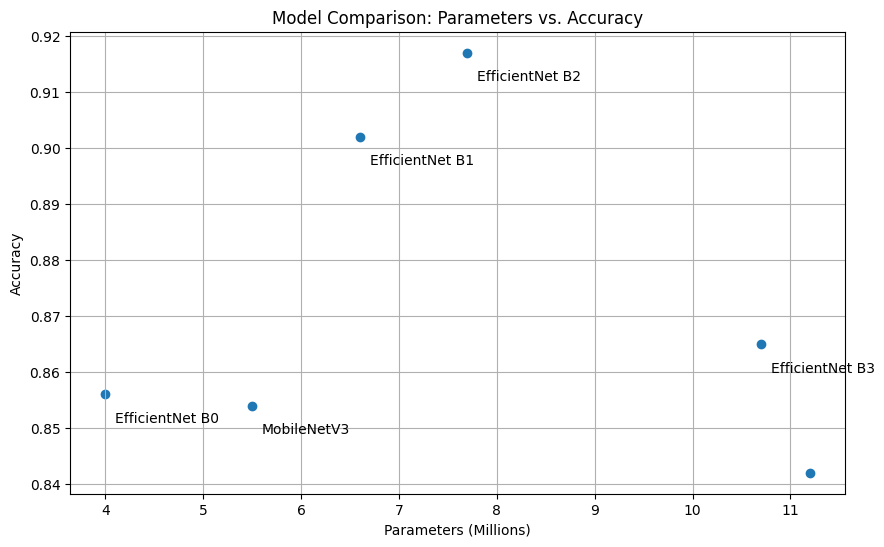

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data provided by the user
data = {
    'Model': ['MobileNetV3', 'EfficientNet B0', 'EfficientNet B1', 'EfficientNet B2', 'EfficientNet B3', 'ResNet18'],
    'Parameters (M)': [5.5, 4.0, 6.6, 7.7, 10.7, 11.2],
    'Accuracy': [0.854, 0.856, 0.902, 0.917, 0.865, 0.842]
}

df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Parameters (M)'], df['Accuracy'])

# Add labels to each point
for i, row in df.iterrows():
    plt.annotate(row['Model'], (row['Parameters (M)'] + 0.1, row['Accuracy'] - 0.005))

plt.title('Model Comparison: Parameters vs. Accuracy')
plt.xlabel('Parameters (Millions)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()